# Occurrence rate

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from scipy.stats import gaussian_kde

In [3]:
from exogaia.data import EpochAstrometry
from exogaia.leastsq import LeastSquares
from exogaia.planets import OccurrenceRate

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [4]:
np.random.seed(42)

In [5]:
occ_rate = OccurrenceRate(primary_mass=np.full(500, 1.0), occ_rate="cls_fulton2021")
sma, mass_planet = occ_rate.sample_planets(allow_reject=False)


---------------
Occurrence rate
---------------

Occurrence rate: cls_fulton2021

Valid ranges:
   - Semi-major axis (au): 0.03 - 30.00
   - Companion mass (Mjup): 0.09 - 18.88

Primary mass range (Msun): 1.00 - 1.00

--------------
Sample planets
--------------

Number of stars: 500
Number of planets: 500

Semi-major axis range (au) = 0.04 - 29.95
Companion mass range (Msun) = 9.10e-05 - 1.79e-02


In [6]:
xy = np.vstack([np.log10(sma), np.log10(mass_planet)])
kde = gaussian_kde(xy)

x_points = np.geomspace(0.04, 100, 200)
y_points = np.geomspace(4e-5, 3e-2, 200)
x_grid, y_grid = np.meshgrid(x_points, y_points)

positions = np.vstack([x_grid.ravel(), y_grid.ravel()])
z_grid = kde(np.log10(positions)).reshape(x_grid.shape)

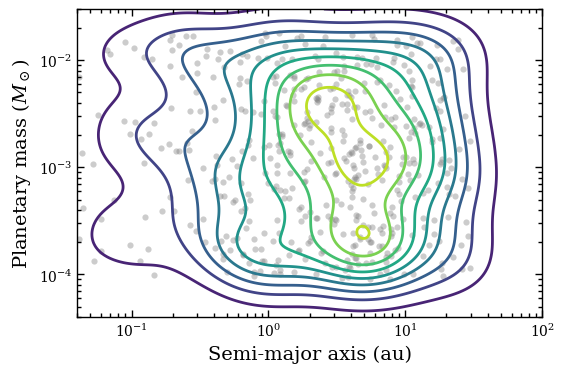

In [7]:
plt.figure(figsize=(6, 4))
plt.scatter(sma, mass_planet, s=20, alpha=0.4, lw=0.0, color="gray")
plt.contour(x_grid, y_grid, z_grid, levels=10, linewidths=2.0)
plt.xlabel("Semi-major axis (au)", fontsize=14)
plt.ylabel("Planetary mass ($M_\odot$)", fontsize=14)
plt.loglog()
plt.show()

In [8]:
source_id = 2603090003484152064  # Gliese 876
primary_mass = (0.35, 0.01)  # (Msun)

In [9]:
epoch_astrom = EpochAstrometry(primary_mass=primary_mass, gaia_release='DR5')


----------------
Epoch astrometry
----------------

Gaia release: DR5
Reference epoch: 2020.0

Primary mass (Msun): 0.35 +/- 0.01


In [10]:
star_param = epoch_astrom.query_source(source_id=source_id, gaia_release='DR3')


---------------
Querying source
---------------

Gaia release: DR3
Source ID: 2603090003484152064

INFO: Query finished. [astroquery.utils.tap.core]

RA = 343.324 deg +/- 0.034 mas
Dec = -14.267 deg +/- 0.026 mas
Parallax = 214.038 +/- 0.036 mas
Proper motion in RA = 957.715 +/- 0.041 mas/yr
Proper motion in Dec = -673.601 +/- 0.031 mas/yr
G-band magnitude = 8.875
Pseudocolor = 1.26 um-1

UWE = 2.82
RUWE = 1.34
Astrometric excess noise (mas) = 0.2433 +/- 0.0043
Non single star = 1


In [11]:
model_param = epoch_astrom.simulate_data(
    model_param=None,
    mass_2=None,
    flux_ratio=None,
    occ_rate="cls_fulton2021",
    sigma_per_ccd=None,
    csv_out=None,
    allow_reject=False,
)


---------------
Occurrence rate
---------------

Occurrence rate: cls_fulton2021

Valid ranges:
   - Semi-major axis (au): 0.03 - 30.00
   - Companion mass (Mjup): 0.09 - 18.88

Primary mass range (Msun): 0.35 - 0.35

--------------
Sample planets
--------------

Number of stars: 1
Number of planets: 1

Semi-major axis (au) = 1.16
Companion mass (Msun) = 3.32e-04

-------------
Simulate data
-------------

System type: binary

Primary mass (Msun): 0.35 +/- 0.01

AL scan uncertainty (per CCD) = 125.70 uas
AL scan uncertainty (per transit) = 44.44 uas

Additional parameters:
   - Primary mass (Msun) = 0.35
   - Companion mass (Msun) = 3.32e-04
   - Mass ratio = 9.49e-04
   - Flux ratio = 2.63e-11
   - Relative semi-major axis (au) = 1.16

-----------------------
Calculate stellar track
-----------------------

Stellar parameters:
   - RA offset (mas) = 0.000
   - Dec offset (mas) = 0.000
   - Parallax (mas) = 214.038
   - Proper motion in RA (mas/yr) = 957.715
   - Proper motion in Dec 

In [12]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Single star (5 parameters)
--------------------------

Reduced chi^2 = 10.036
RUWE = 3.168
F2 estimator = 24.344
Inflation factor = 3.179

Best-fit parameters:
   - RA offset = 0.023 +/- 0.013 mas
   - Dec offset = -0.035 +/- 0.010 mas
   - Parallax = 214.018 +/- 0.015 mas
   - mu in RA = 957.724 +/- 0.005 mas/yr
   - mu in Dec = -673.593 +/- 0.003 mas/yr


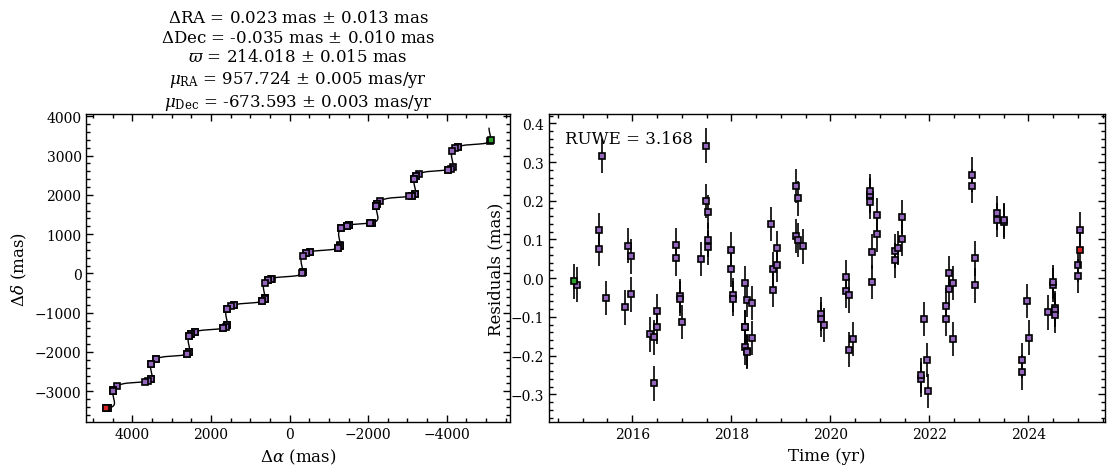

In [13]:
results = leastsq.singl_5param(plot_file='plot.png')


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 2.147

Best-fit stellar track:
   - RA offset (mas) = -0.030 +/- 0.014
   - Dec offset (mas) = -0.055 +/- 0.011
   - Parallax (mas) = 214.014 +/- 0.012
   - mu in RA (mas/yr) = 957.713 +/- 0.004
   - mu in Dec (mas/yr) = -673.591 +/- 0.003

Best-fit orbit:
   - Period (days) = 853.168
   - Eccentricity = 0.333
   - Relative time of periastron = 0.53
   - Thiele-Innes A = -0.019 +/- 0.012
   - Thiele-Innes B = -0.114 +/- 0.017
   - Thiele-Innes F = -0.118 +/- 0.013
   - Thiele-Innes G = 0.145 +/- 0.016

Derived parameters:
   - Semi-major axis of photocenter (mas) = 0.205 +/- 0.015
   - Relative semi-major axis (au) = 1.241
   - Mass function (Msun) = 1.612e-10
   - Companion mass (Msun) = 2.704e-04

Conversion to campbell elements:
   - Period = 853.168 days
   - Eccentricity = 0.333
   - Relative time of periastron = 0.533
   - Semi-major axis of photocenter (mas) = 0.205
   - Inclination (deg) = 112.697
   - Argument of periastron (deg) = 243.715
   - PA of ascending

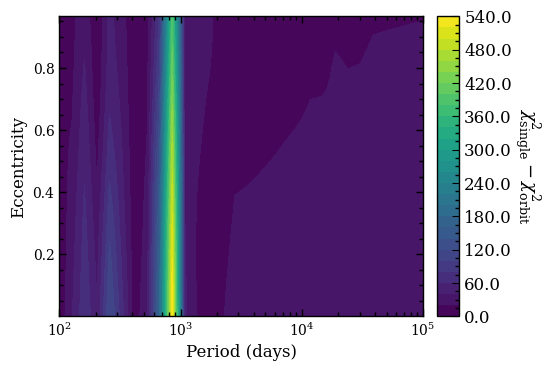

In [14]:
results = leastsq.orbit_grid(n_points=30, map_type='chi2_det', plot_file='plot.png')


-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 0.530
RUWE: 0.728

Best-fit stellar track:
   - RA offset (mas) = 0.007 +/- 0.023
   - Dec offset (mas) = -0.014 +/- 0.020
   - Parallax (mas) = 214.027 +/- 0.009
   - mu in RA (mas/yr) = 957.719 +/- 0.003
   - mu in Dec (mas/yr) = -673.600 +/- 0.002

Best-fit orbit:
   - Period (days) = 771.391 +/- 3.439
   - Eccentricity = 0.168 +/- 0.077
   - Relative time of periastron = 0.301 +/- 0.069
   - Semi-major axis of photocenter (mas) = 0.235 +/- 0.009
   - Inclination (deg) = 111.110 +/- 2.910
   - Argument of periastron (deg) = 171.462 +/- 26.556
   - PA of ascending node (deg) = 127.490 +/- 2.987

Number of function evaluations: 14
Number of Jacobian evaluations: 14

Derived parameters:
   - Relative semi-major axis (au) = 1.160
   - Mass function (Msun) = 2.976e-10
   - Companion mass (Msun) = 3.318e-04


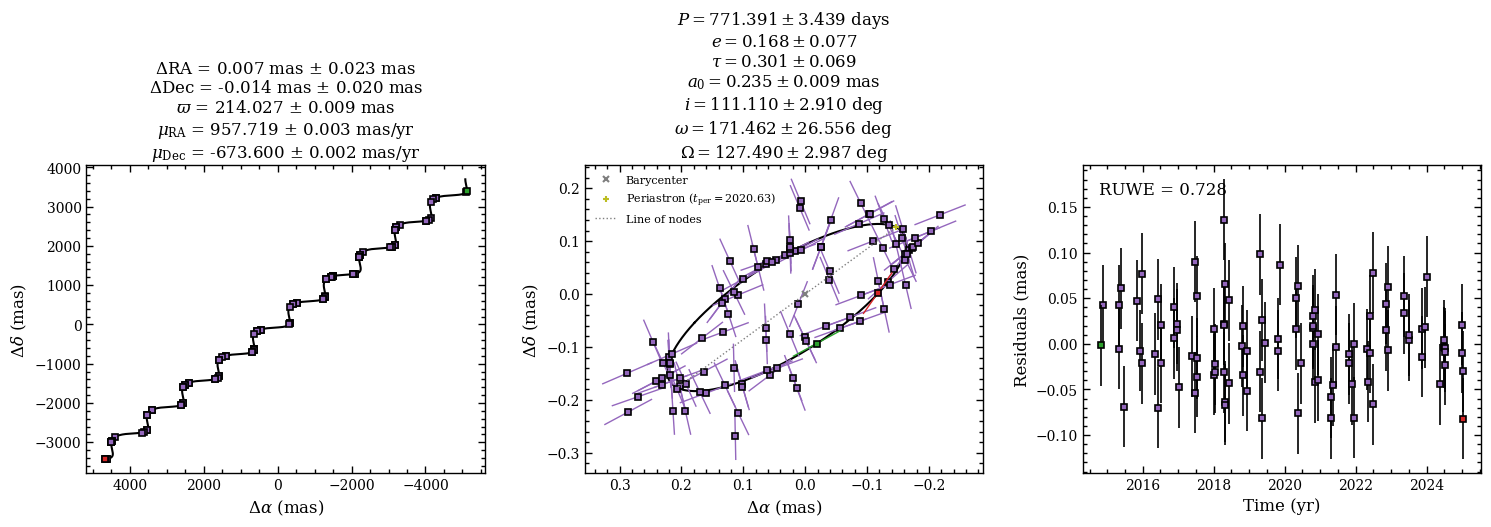

In [15]:
results = leastsq.orbit_fit(inc_jitter=False, plot_file='plot.png')